# Import Library

In [39]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

# Load Data

In [40]:
train = pd.read_csv('Watches_train_cleaned.csv') 
test = pd.read_csv('Watches_test_cleaned.csv') 
print ('Train shape: ' , train.shape, 'Test shape: ', test.shape)
print(); print ('Train'); print (train.info())
print(); print ('Test'); print (test.info()) 

Train shape:  (198927, 12) Test shape:  (49671, 12)

Train
<class 'pandas.DataFrame'>
RangeIndex: 198927 entries, 0 to 198926
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   name          146349 non-null  str    
 1   price         198927 non-null  float64
 2   brand         198927 non-null  str    
 3   model         198927 non-null  str    
 4   ref           175329 non-null  str    
 5   mvmt          198927 non-null  str    
 6   casem         198927 non-null  str    
 7   bracem        198927 non-null  str    
 8   yop           198927 non-null  float64
 9   cond          198927 non-null  str    
 10  is_female     198927 non-null  float64
 11  case_size_mm  184810 non-null  float64
dtypes: float64(4), str(8)
memory usage: 18.2 MB
None

Test
<class 'pandas.DataFrame'>
RangeIndex: 49671 entries, 0 to 49670
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        -----

# Analyze Nen values 

In [41]:
def nan_report (df): 
    summary = pd.DataFrame({
        'dtype': df.dtypes.astype (str), 
        'missing_count': df.isna().sum(), 
        'missing_proportion': df.isna().mean() * 100, 
        'n_unique': df.nunique(dropna = False) 
    })
    summary = summary[summary['missing_proportion'] != 0]
    return summary.sort_values ('missing_proportion', ascending = False)
print ('train'); print (nan_report(train)); print() 
print ('test');print (nan_report(test)); print() 

train
                dtype  missing_count  missing_proportion  n_unique
name              str          52578           26.430801    104860
ref               str          23598           11.862643     28937
case_size_mm  float64          14117            7.096573       453

test
                dtype  missing_count  missing_proportion  n_unique
name              str          13049           26.270862     30917
ref               str           6017           12.113708     15283
case_size_mm  float64           3577            7.201385       317



# Analyze the target value

In [42]:
train['price'].describe()

count    1.989270e+05
mean     1.916906e+04
std      5.988812e+04
min      4.000000e+01
25%      3.302000e+03
50%      7.345000e+03
75%      1.676200e+04
max      8.778828e+06
Name: price, dtype: float64

In [43]:
train['price'].skew() 

np.float64(40.101180192825694)

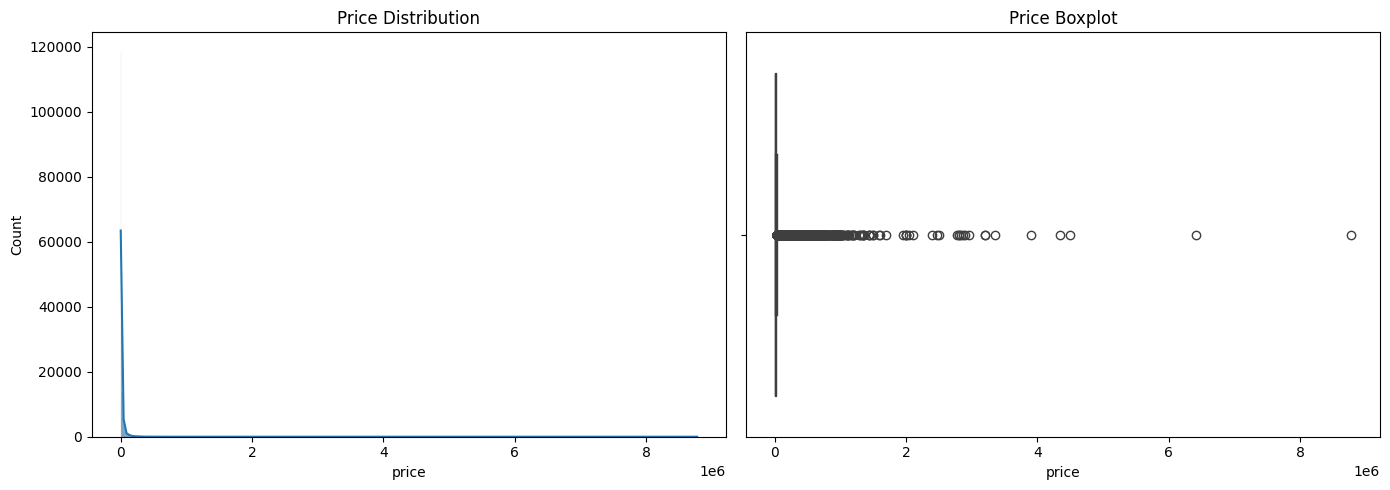

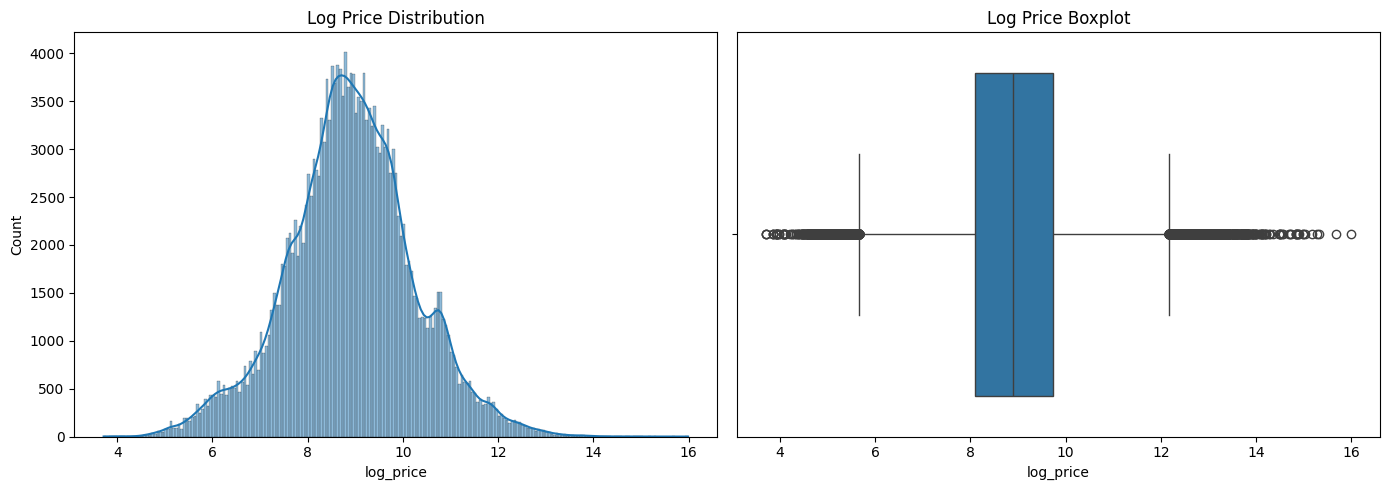

In [44]:
fig, ax = plt.subplots (1, 2, figsize = (14, 5)) 
sns.histplot (train['price'], kde = True, ax = ax[0]) 
ax[0].set_title ('Price Distribution') 
sns.boxplot (x = train['price'], ax = ax[1])
ax[1].set_title ('Price Boxplot') 

plt.tight_layout() 
plt.show() 

train['log_price'] = np.log1p (train['price'])
fig, ax = plt.subplots (1, 2, figsize = (14, 5)) 
sns.histplot (train['log_price'], kde = True, ax = ax[0])
ax[0].set_title ('Log Price Distribution') 
sns.boxplot (x = train['log_price'], ax = ax[1]) 
ax[1].set_title ('Log Price Boxplot') 
plt.tight_layout()
plt.show() 

As can be seen, the price distribution looks much cleaner when they are processed with log1P

# Plot numerical feature correlation with target

In [45]:
train["watch_age"] = 2024 - train['yop']
num_cols = ['yop', 'watch_age', 'case_size_mm']  

# Correlation matrix
train[num_cols + ['log_price']].describe() 
train[num_cols + ['log_price']].corr (numeric_only = True)

,yop,watch_age,case_size_mm,log_price
yop,1.000000,-1.000000,0.102141,0.078832
watch_age,-1.000000,1.000000,-0.102141,-0.078832
case_size_mm,0.102141,-0.102141,1.000000,0.137666
log_price,0.078832,-0.078832,0.137666,1.000000


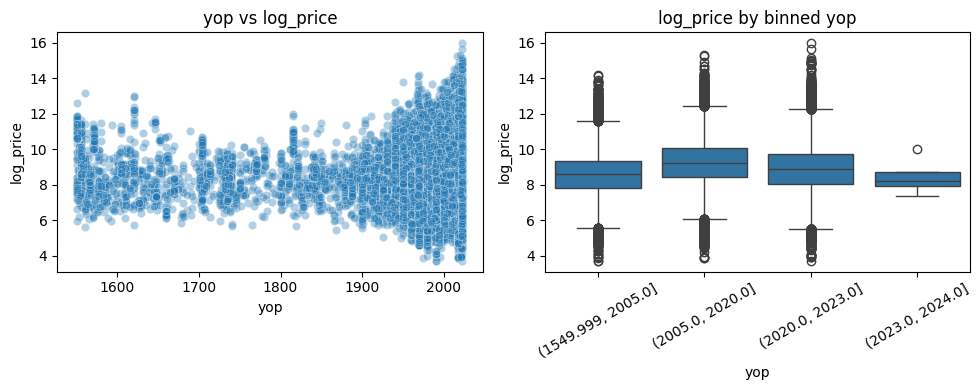

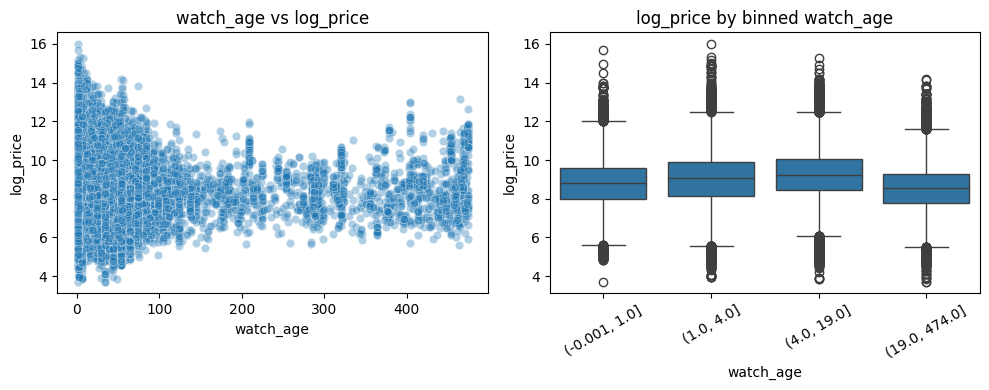

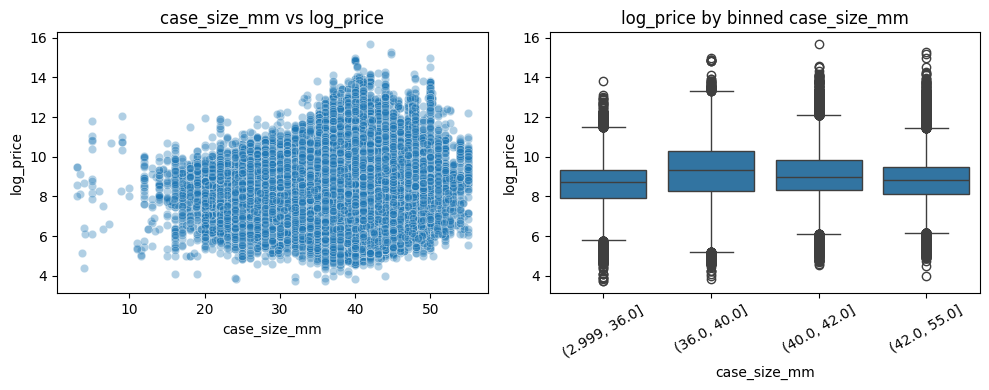

In [46]:
for col in ['yop', 'watch_age', 'case_size_mm']: 
    fig, ax = plt.subplots (1, 2, figsize = (10,4)) 
    sns.scatterplot (
        data = train, 
        x = col, 
        y = 'log_price', 
        alpha = 0.35, 
        ax = ax[0], 
    )
    ax[0].set_title (f"{col} vs log_price") 
    binned = pd.qcut (
        train[col], 
        q = 4, 
        duplicates='drop'
    ) 

    sns.boxplot (
        data = train, 
        x = binned, 
        y = 'log_price', 
        ax = ax[1], 
    )

    ax[1].set_title (f'log_price by binned {col}')
    ax[1].tick_params(axis = 'x', rotation = 30)

    plt.tight_layout()
    plt.show() 

Analysis: 
* The age of the watch doesn't have a linear relationship with the price of the watch. 
* Newer watch covers a great range of price. 
* Watches in the middle have more median than newer or older watches. 
* Very old watches and very new watches have different distributions, but the medians do not move significantly. 
* case_size_mm scaterrs in some certain patterns, but doesn't show a notable signal.

Conclusion: 
* Three features have clear overlap between bins. 
* These features don't strongly predict price. 
* The should be combined with other features to refine the prediction. 

# Plot Categorical correlation with target feature 

'brand' feature

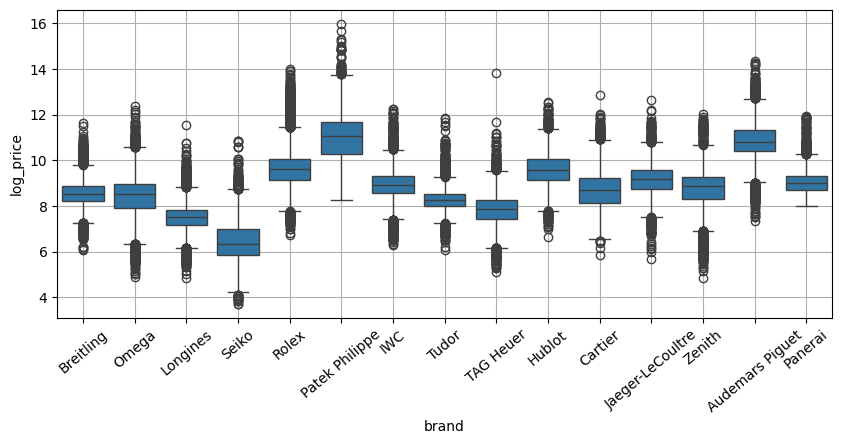

In [47]:
# Select top 15 most prevalent brands 
top_brands = train['brand'].value_counts().head(15).index
subset = train[train['brand'].isin (top_brands)]
plt.figure (figsize = (10, 4))
sns.boxplot (
    data = subset, 
    x = 'brand',
    y = 'log_price', 
)
plt.grid (True)
plt.tick_params(axis = 'x', rotation = 40)
plt.show () 

Analysis: 
* The median price differs a lot across brands, especially when compared to the difference of the numerical features like yop and case size
* Some brands clearly have high medians, like 'Patek Phillippe', 'Audemars Piguet'
* Spread between brand is pretty large, 'Seiko' and 'Rolex' have a great difference in median. 
* Brands like 'Omega', 'Seiko', 'Rolex', 'Cartier' have cover a greater range of median price than others 

Conclusion: 
* Brand is a major feature driving the price 
* Brand alone is not enough due to large median gap between brands
* ML model needs more information to self-explain the variation within each brand 
* Outliers need considering, brands like Patek stands out apparently in median price

'model' feature 

In [48]:
# Top 20 most prevalent models
train.groupby('model')['log_price'].agg([
    'count', 
    'median', 
    'mean', 
    'std',
]).sort_values('count', ascending=False).head(20) 

,count,median,mean,std
model,,,,
Datejust 36,6989,9.176887,9.222854,0.460574
Daytona,5357,10.667466,10.743246,0.591351
Datejust 41,4634,9.627602,9.605446,0.202200
5,4511,7.523481,7.507652,1.678850
Submariner Date,3962,9.773834,9.851358,0.452491
Lady-Datejust,3419,8.909370,9.008261,0.561182
GMT-Master II,3340,9.963477,10.031852,0.473555
Prospex,3253,6.620073,6.770672,0.709397
Seamaster Aqua Terra,3182,8.687779,8.721571,0.576900


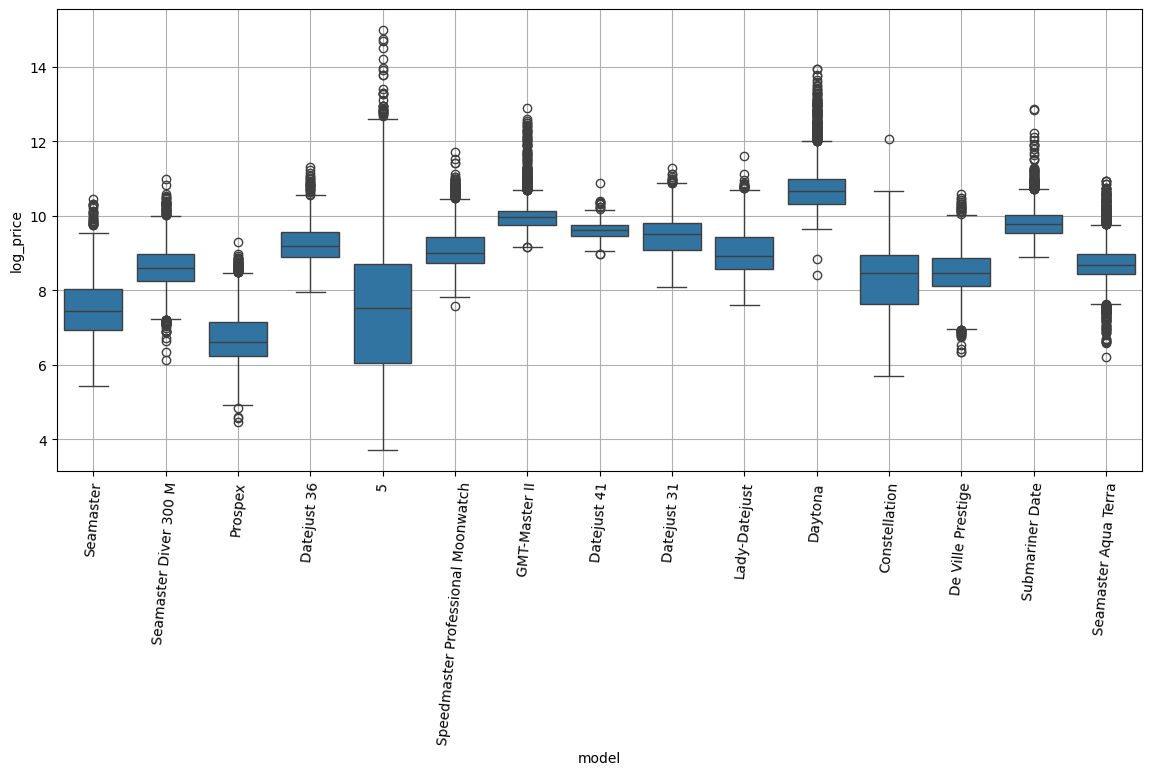

In [49]:
#Plot the top 15 most prevalent models
top_models = train['model'].value_counts().head(15).index
subset = train[train['model'].isin (top_models)] 
plt.figure (figsize = (14, 6)) 
sns.boxplot (
    data = subset, 
    x = 'model', 
    y = 'log_price', 
) 
plt.grid (True) 
plt.tick_params(
    axis = 'x', 
    rotation = 85, 
)

Analysis: 
* The table and the illustration there's also a significant difference in median price between models 
* Some models like 'Daytona' has a clear upper median than the others 
* There is a great variation between the median of the models 

Conclusion: 
* Model is also a great driver to the change in price 
* Model itself alone is insufficient to predict price because of its great variabation in median 

'brand' combined with 'model'

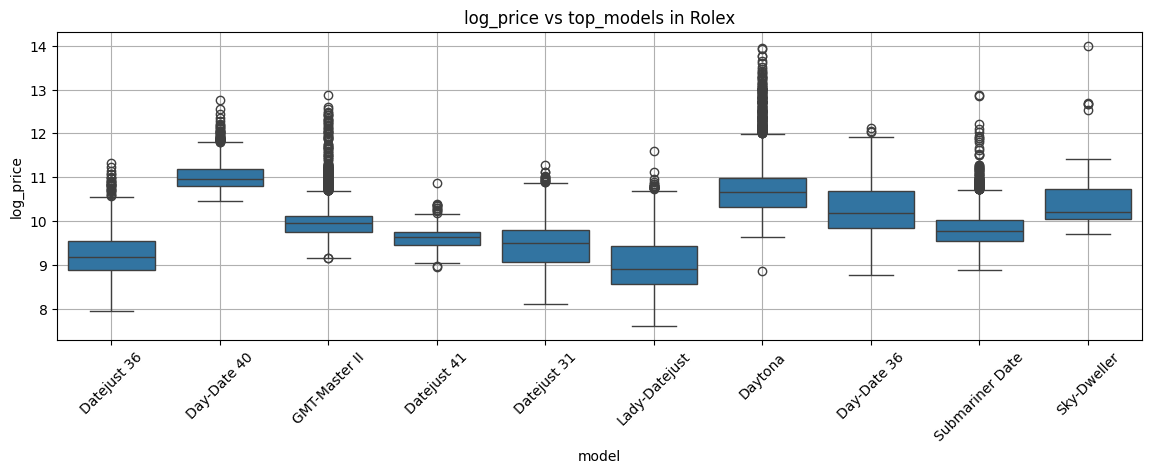

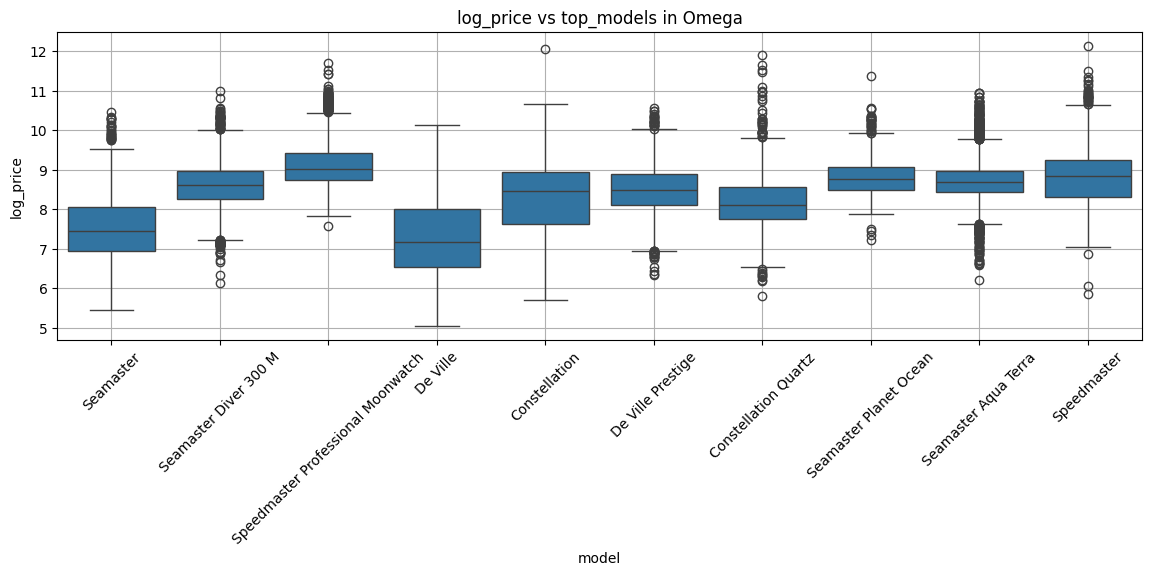

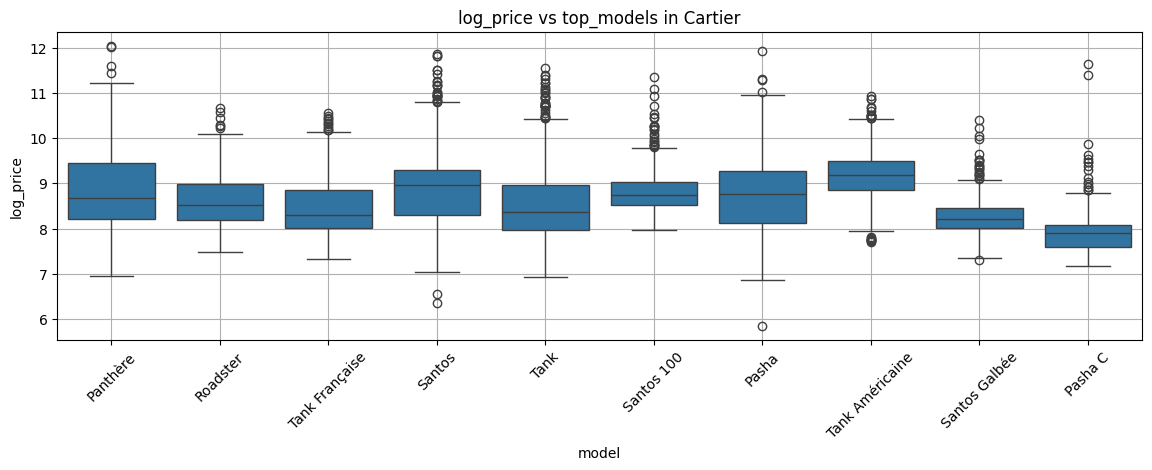

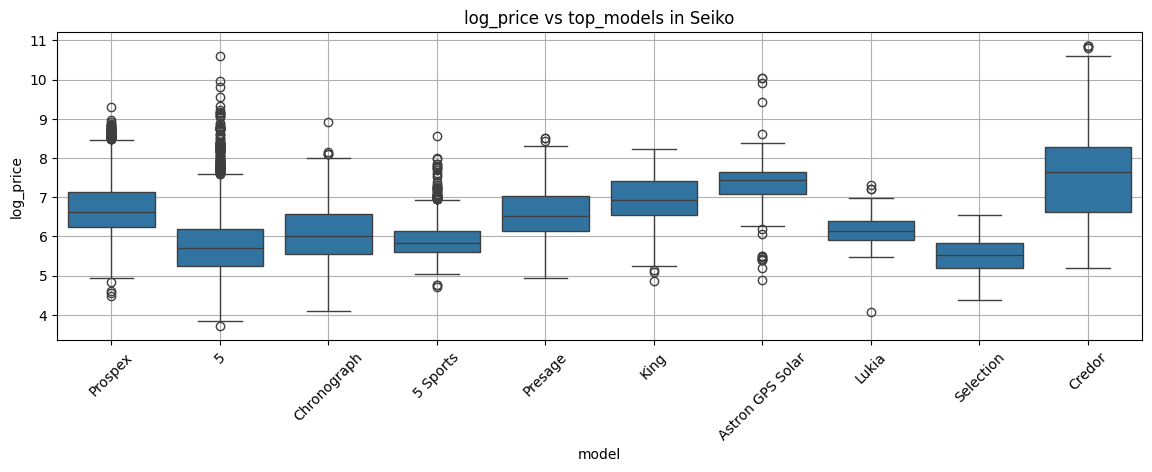

In [50]:
brands_great_range = ['Rolex', 'Omega', 'Cartier', 'Seiko']
for brand in brands_great_range: 
    brand_df = train[train['brand'] == brand] 
    # Select top 10 models of each brand
    top_models = brand_df['model'].value_counts().head(10).index
    subset = brand_df[brand_df['model'].isin (top_models)] 
    plt.figure (figsize= (14, 4))
    sns.boxplot (
        data = subset, 
        x = 'model', 
        y = 'log_price', 
    )
    plt.tick_params(axis = 'x', rotation = 45)
    plt.title (f'log_price vs top_models in {brand}') 
    plt.grid (True)
    plt.show()

Analysis: 
* Rolex has a strong in median price distribution between its models 
* Omega also has strong difference in median, but less significant
* Cartier has milder seperation between model's median price 
* Seiko also has strong differences internally between models, though not as clearly as rolex

Conclusion: 
* Brand or model alone is clearly insufficient to tell the difference in price distribution 

In [51]:
train.groupby(['brand', 'model'])['log_price'].agg([
    'count', 
    'median',
    'mean', 
    'std', 
]).reset_index().sort_values('median', ascending = False)

,brand,model,count,median,mean,std
816,Patek Philippe,Sky Moon Tourbillon,1,15.987854,15.987854,NaN
839,Richard Mille,RM 052,2,14.614933,14.614933,0.150295
832,Richard Mille,RM 027,1,14.173151,14.173151,NaN
809,Patek Philippe,Minute Repeater Perpetual Calendar,16,13.858141,13.920612,0.746848
22,A. Lange & Söhne,Tourbograph,1,13.714369,13.714369,NaN
...,...,...,...,...,...,...
1064,TAG Heuer,Vintage,2,5.555447,5.555447,0.190795
948,Seiko,Selection,226,5.531409,5.545258,0.428273
954,Seiko,Style,2,5.427244,5.427244,0.323498
949,Seiko,Solar,142,5.416091,5.444705,0.675105


* Some model has too few instances to be used for dictating price
* Some model can also have very different distribution because of its few samples 

In [52]:
model_counts = train['model'].value_counts()
print ('The proportion of model with < 10 instances: ', (model_counts < 10).mean() * 100)

The proportion of model with < 10 instances:  16.10810810810811


Analysis: 
* brand and model are important, but model is sparse
* 16% of models has less than 10 instances 

Conclusion: 
* rare-category may be needed later to warn the model of sparse model 
* only trust combinations of brand-model with enough sample. 

In [53]:
brand_model_counts = (
    train.groupby(['brand', 'model'])
).size().reset_index(name = 'count').sort_values(
    'count', 
    ascending = False, 
)
# Get the top 15 most prevalent models in each brand 
brand_model_counts.head (15)

,brand,model,count
858,Rolex,Datejust 36,6989
868,Rolex,Daytona,5356
859,Rolex,Datejust 41,4634
898,Rolex,Submariner Date,3962
873,Rolex,Lady-Datejust,3419
872,Rolex,GMT-Master II,3340
946,Seiko,Prospex,3253
633,Omega,Seamaster Aqua Terra,3182
636,Omega,Seamaster Diver 300 M,3075
629,Omega,Seamaster,2725


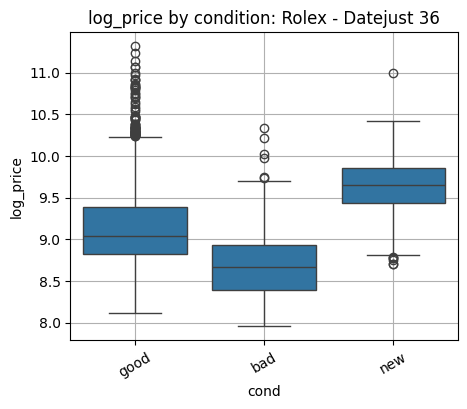

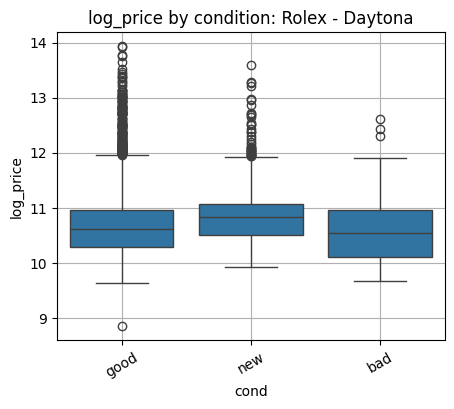

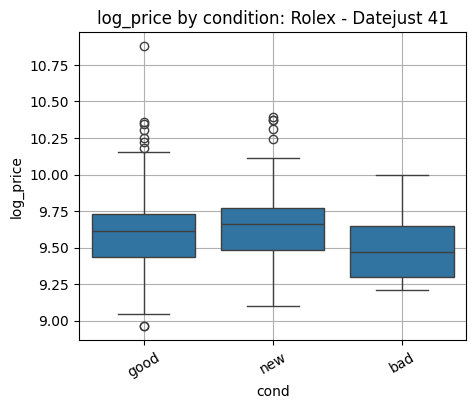

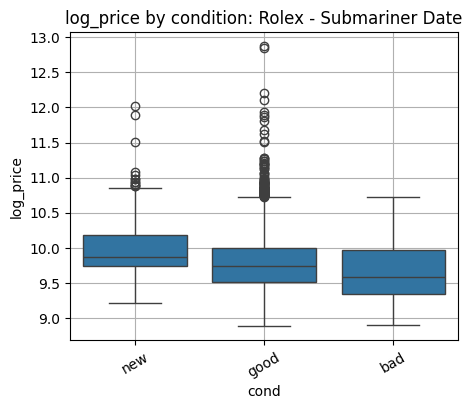

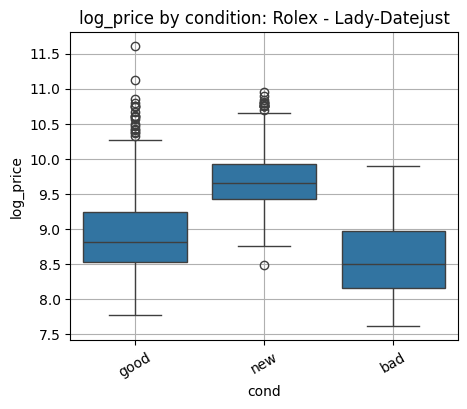

In [54]:
# Choose the top 5 brand-model paris 
top_pairs = brand_model_counts.head (5)[['brand', 'model']] 
for _, row in top_pairs.iterrows(): 
    brand = row['brand'] 
    model = row['model'] 
    subset = train[(train['brand'] == brand) & (train['model'] == model)]
    plt.figure (figsize = (5, 4))
    sns.boxplot (
        data = subset, 
        x = 'cond', 
        y = 'log_price', 
    )
    plt.tick_params(axis = 'x', rotation = 45)
    plt.grid (True) 
    plt.title (f'log_price by condition: {brand} - {model}') 
    plt.xticks (rotation = 30) 
    plt.show () 

In [55]:
# Check for pairs with over 100 counts 
common_pairs = brand_model_counts[brand_model_counts['count'] >= 100].sort_values(
    'count', 
    ascending = False, 
)

condition_table = (
    train.merge (
        common_pairs[['brand', 'model']], 
        on = ['brand', 'model'], 
    ).groupby(['brand', 'model', 'cond'])['log_price'].agg ([
        'count', 
        'median', 
        'mean', 
        'std'
    ]).reset_index()
)

condition_pivot = condition_table.pivot_table(
    index = ['brand', 'model'],  
    columns = 'cond', 
    values = [
        'count', 
        'median', 
        'mean', 
        'std', 
    ]
)

condition_pivot

count                    mean  \
cond                                       bad   good   new        bad   
brand            model                                                   
A. Lange & Söhne 1815                      1.0  106.0  23.0  10.600975   
                 Lange 1                   2.0  192.0  24.0  10.130177   
                 Saxonia                   2.0  101.0  19.0  10.192650   
Audemars Piguet  5                         6.0   92.0  12.0   8.316766   
                 Code 11.59                4.0  176.0  59.0  10.392865   
...                                        ...    ...   ...        ...   
Zenith           El Primero Chronomaster   6.0  393.0  69.0   8.332284   
                 Elite                     2.0  186.0  39.0   7.777088   
                 Pilot                     7.0  136.0  52.0   6.693834   
                 Port Royal                8.0  111.0  15.0   7.796432   
                 Stellina                  4.0   96.0   3.0   6.718657   

                                                                   median  \
cond                                           good        new        bad   
brand            model                                                      
A. Lange & Söhne 1815                     10.557869  11.030075  10.600975   
                 Lange 1                  10.683023  10.947770  10.130177   
                 Saxonia                  10.213024  10.292016  10.192650   
Audemars Piguet  5                         9.831070  10.482030   8.306305   
                 Code 11.59               10.624122  10.677488  10.138972   
...                                             ...        ...        ...   
Zenith           El Primero Chronomaster   8.904783   9.047230   8.317199   
                 Elite                     8.576849   8.835702   7.777088   
                 Pilot                     8.640782   8.769051   6.529419   
                 Port Royal                7.752425   7.738903   7.884864   
                 Stellina                  7.140285   6.945910   6.833563   

                                                                     std  \
cond                                           good        new       bad   
brand            model                                                     
A. Lange & Söhne 1815                     10.544582  10.900971       NaN   
                 Lange 1                  10.592910  10.770357  0.327606   
                 Saxonia                  10.196008  10.242777  0.642440   
Audemars Piguet  5                         9.667996  10.851282  0.623810   
                 Code 11.59               10.542716  10.731908  0.561267   
...                                             ...        ...       ...   
Zenith           El Primero Chronomaster   8.902456   9.015055  0.337029   
                 Elite                     8.646197   8.814182  0.298083   
                 Pilot                     8.783084   8.822655  0.832396   
                 Port Royal                7.845416   7.880804  0.187710   
                 Stellina                  7.043585   6.692084  0.479271   

                                                              
cond                                          good       new  
brand            model                                        
A. Lange & Söhne 1815                     0.589714  0.644818  
                 Lange 1                  0.400041  0.531181  
                 Saxonia                  0.375105  0.406371  
Audemars Piguet  5                        1.107834  1.264990  
                 Code 11.59               0.507941  0.582683  
...                                            ...       ...  
Zenith           El Primero Chronomaster  0.383584  0.249818  
                 Elite                    0.546763  0.438535  
                 Pilot                    0.694588  0.467313  
                 Port Royal               0.949196  0.811527  
                 Stellina                

Analysis: 
* condition does appear to signal the price of watches 
* The strength of difference impacted by cond varies on different models, depending on the number of instances
* The distribution of condition level (bad, good, new) shows consistency for models with over 100 instances
* 'Daytona' model almost has the same median price, regardless of condition 

Conclusion: 
* Ordinal encoding is needed for this feature 
* Condition itself is a good feature for prediction, but unstable because of its variation between models, depending on the sufficiency of instances 

'mvmt' feature 

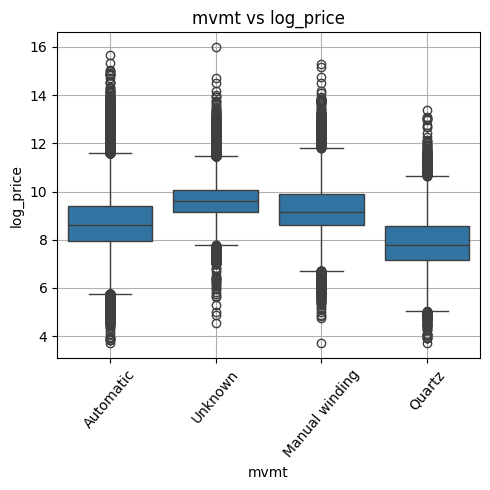

In [56]:
top_mvmt = train ['mvmt'].value_counts().head(10).index
subset = train[train['mvmt'].isin (top_mvmt)]
plt.figure (figsize = (5,5))
sns.boxplot(
    data = subset,
    x = 'mvmt', 
    y = 'log_price', 
)
plt.title (f'mvmt vs log_price') 
plt.grid(True)
plt.xticks(rotation = 50)
plt.tight_layout()
plt.show() 

In [57]:
train[train['mvmt'] == 'Unknown']['brand'].value_counts().head (10) 

brand
Rolex               51991
Tudor                  55
Seiko                  24
Breitling              16
Sinn                   13
TAG Heuer              12
Jaeger-LeCoultre       10
Panerai                 7
Hublot                  4
Oris                    4
Name: count, dtype: int64

In [58]:
train['is_quartz'] = (train['mvmt'] == 'Quartz').astype (int)
train.groupby('is_quartz')['log_price'].agg ([
    'count', 
    'median', 
    'mean', 
    'std', 
]).sort_values('median', ascending = False)

,count,median,mean,std
is_quartz,,,,
0,175653,9.023529,9.053555,1.288743
1,23274,7.794411,7.855262,1.164374


Analysis: 
* Quartz clearly has lower price 
* Unknown is dominated by Rolex watches, explaining its high median price
* Manual winding somehow has higher price median than Automatic 

Conclusion: 
* mvmt does have signal, but the result needs careful interpretation
* mvmt is likely a useful predictor
* Quartz and not-quartz should be the most major difference 

'casem' and 'bracem' feature 

In [67]:
casem_summary = train.groupby('casem')['log_price'].agg ([
    'count', 
    'median', 
    'mean', 
    'std', 
]).sort_values('median', ascending = False)

bracem_summary = train.groupby('bracem')['log_price'].agg ([
    'count', 
    'median', 
    'mean', 
    'std', 
]).sort_values('median', ascending = False)

print (casem_summary); print()
print (bracem_summary); print()

           count     median       mean       std
casem                                           
Rare       21417  10.519700  10.489681  1.027584
Valuable   38412   9.380168   9.380594  0.988920
Common    111119   8.617220   8.611866  1.121423
Unknown    27979   8.238801   8.262646  1.574128

           count     median       mean       std
bracem                                          
Rare       16277  10.550591  10.395479  1.133908
Valuable  145323   8.881975   8.905664  1.156393
Common      6193   8.386857   8.194891  1.409070
Unknown    31134   8.300777   8.317320  1.554395



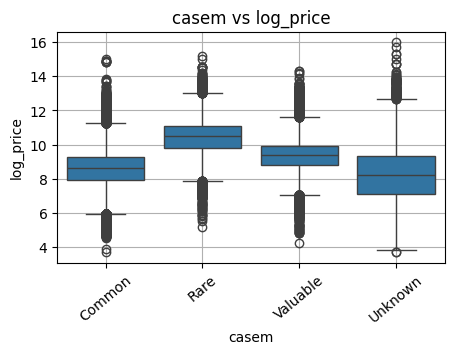

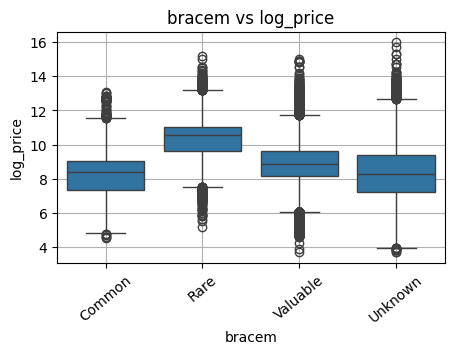

In [73]:
top_casem = train['casem'].value_counts().head(10).index
subset = train[train['casem'].isin (top_casem)]
plt.figure (figsize = (5, 3))
sns.boxplot (
    data = subset, 
    x = 'casem', 
    y = 'log_price', 
    order = ['Common', 'Rare', 'Valuable', 'Unknown'], 
)
plt.tick_params(axis = 'x', rotation = 40)
plt.grid (True)
plt.title ('casem vs log_price') 
plt.show()

top_bracem = train['bracem'].value_counts().head(10).index
subset = train[train['bracem'].isin (top_bracem)]
plt.figure (figsize = (5, 3))
sns.boxplot (
    data = subset, 
    x = 'bracem', 
    y = 'log_price', 
    order = ['Common', 'Rare', 'Valuable', 'Unknown'], 
)
plt.tick_params(axis = 'x', rotation = 40)
plt.grid (True)
plt.title ('bracem vs log_price') 
plt.show()

In [81]:
total_pairs = train.groupby(['brand', 'model']).size() 
unknown_casem = train[train['casem'] == 'Unknown'].groupby([
    'brand', 
    'model', 
]).size() 

casem_summary = pd.concat ([total_pairs, unknown_casem], axis = 1).fillna(0)
casem_summary.columns = ['total_count', 'unknown_count']
casem_summary['unknown_rate'] = casem_summary['unknown_count'] / casem_summary['total_count']
casem_summary = casem_summary[casem_summary['total_count'] >= 100] 
print ('Casem'); print (casem_summary.sort_values('unknown_rate', ascending = False).head (10)); print()

unknown_bracem = train[train['bracem'] == 'Unknown'].groupby([
    'brand', 
    'model', 
]).size() 

bracem_summary = pd.concat ([total_pairs, unknown_bracem], axis = 1).fillna(0)
bracem_summary.columns = ['total_count', 'unknown_count']
bracem_summary['unknown_rate'] = bracem_summary['unknown_count'] / bracem_summary['total_count']
bracem_summary = bracem_summary[bracem_summary['total_count'] >= 100] 
print ('Bracem'); print (bracem_summary.sort_values('unknown_rate', ascending = False).head (10)); print() 

Casem
                              total_count  unknown_count  unknown_rate
brand            model                                                
Jaeger-LeCoultre Atmos                103           93.0      0.902913
Breitling        Premier              113          102.0      0.902655
Seiko            Vintage              105           91.0      0.866667
                 Selection            226          192.0      0.849558
Zenith           Stellina             103           87.0      0.844660
Longines         Vintage              185          154.0      0.832432
Breitling        Chronograph          326          271.0      0.831288
Omega            Vintage              287          224.0      0.780488
Cartier          5                    132          102.0      0.772727
Breitling        5                    270          203.0      0.751852

Bracem
                              total_count  unknown_count  unknown_rate
brand            model                                         

Analysis: 
* There's a minor difference between the distribution of 'Valuable' category between the two features 
* Other categories has identical spreads
* The unknown rate of casem and bracem is very identical between the model - pair
* There is clear ordinal pattern as expected: common < valuable < rare

Conclusion: 
* Unknown doesn't reflect much information
* Grouping casem and bracem will be better

Check if missing values of case related to log_price

In [91]:
print ('ref')
ref_missing = train.groupby(train['ref'].isna())['log_price'].agg ([
    'count', 
    'mean',
    'median', 
]); print (ref_missing); print()

print ('name')
name_missing = train.groupby(train['name'].isna())['log_price'].agg ([
    'count', 
    'mean', 
    'median', 
]); print (name_missing); print()

print ('case')
case_missing = train.groupby(train['case_size_mm'].isna())['log_price'].agg ([
    'count', 
    'mean', 
    'median', 
]);print (case_missing); print() 

ref
        count      mean    median
ref                              
False  175329  9.028577  8.986071
True    23598  8.057294  8.037058

name
        count      mean    median
name                             
False  146349  8.648747  8.573952
True    52578  9.649890  9.609519

case
               count      mean    median
case_size_mm                            
False         184810  8.952377  8.928508
True           14117  8.402543  8.354910



The difference between missing and non-missing of the three features is quite significant. Thereby, it may have some values adding these features as flags. 

# EDA Summary 

* brand and model are the strongest features for prediction 
* cond has moderate ordinal signal 
* casem and bracem should better be grouped 
* quartz should be used as a flag
* mvmt = Unknown is mainly dominated by 'Rolex'
* missingness in name, ref, case carries some signals for prediction 
* yop should be removed 